# Worked content-sequence analysis

This notebook demonstrates the complete `contentsequence` workflow, including loading a bounded content measure, specifying and modifying priors, fitting the linear–sinusoidal model, evaluating posterior diagnostics, generating posterior predictive HDIs, and comparing models using leave-one-out (LOO) cross-validation.

In [2]:
# Import the modelling package and the libraries used for tables and plots.
import contentsequence as cs
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

## Load and validate the data

The following example consists of a normalized content location variable (`time`) and a bounded content measure (`emo`).

To ensure valid model estimation:
- `time` must be strictly increasing and bounded between `0` and `1`.
- `emo` represents the content measure and must remain within specified lower and upper bounds. By default, the content measure is assumed to be bounded within `[0, 100]`, but these bounds can be adjusted to reflect the scale of your data.

(0.0, 1.0)

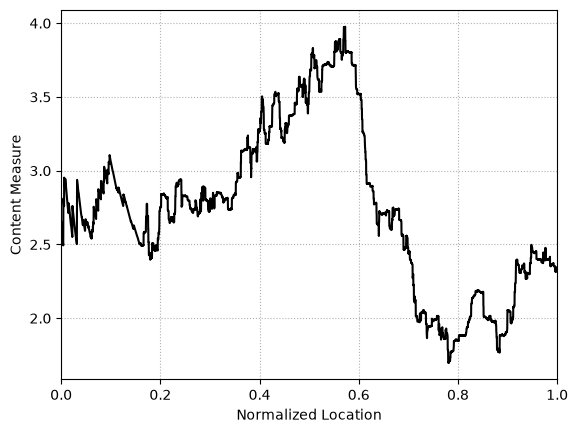

In [3]:
# Load the example data from the CSV file.
data = pd.read_csv("8883_emo_sequence.csv")

# Plot the observed sequence before fitting a model.
plt.plot(data.time, data.emo, color='k')
plt.grid(ls=":")
plt.xlabel("Normalized Location")
plt.ylabel("Content Measure")
plt.xlim(0, 1)

## Fit the linear-sinusoidal model

We now fit the proposed linear-sinusoidal model:
$$
S(t) = c + m t + a \sin(2 \pi f t - u),
$$
where $c$ is the linear intercept, $m$ is the linear trend, $a$ is the sinusoidal amplitude, $f$ is frequency in cycles per normalized sequence, and $u$ is phase in radians.

Note: The two prior lines below are optional: `mu` is the expected linear intercept and `sigma` describes uncertainty around it. Delete these two lines to use the default linear intercept prior.

In [4]:
# Create the linear-sinusoidal model
model = cs.LinearSinusoidalModel()

# Optional: change the priors
# e.g., linear intercept location and its uncertainty
model.priors.linear_intercept.mu = 10
model.priors.linear_intercept.sigma = 3

# Give the model the location and sequence data
model.time_data = data.time
model.sequence_data = data.emo

# Fit the model
# This may take a couple of minutes depending on the size of the data
idata = model.fit(progressbar=False)

Sampling: [dof_unconstrained, observed, polynomial_coeffs, sigma, sinusoidal_amplitude, sinusoidal_frequency, sinusoidal_phase]
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [polynomial_coeffs, sinusoidal_amplitude, sinusoidal_frequency, sinusoidal_phase, sigma, dof_unconstrained]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 213 seconds.
Sampling: [observed]


### Diagnose the posterior chains

The ArviZ summary reports 95% HDIs, rank-normalized R-hat, and effective sample sizes. R-hat should be close to 1, effective sample sizes should be adequate for the estimates of interest, trace plots should mix without persistent structure, and sampling should report no divergences. These checks precede substantive interpretation.

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
opening_position,3.217,0.013,3.190,3.240,0.000,0.000,2320.092,2659.267,1.002
opening_direction,-6.997,0.062,-7.116,-6.877,0.001,0.001,2915.844,2574.999,1.000
linear_trend,-0.787,0.012,-0.809,-0.764,0.000,0.000,2400.139,2752.185,1.001
sinusoidal_amplitude[0],0.665,0.005,0.654,0.675,0.000,0.000,4001.519,2941.769,1.000
sinusoidal_frequency[0],1.492,0.004,1.483,1.500,0.000,0.000,2182.068,2222.404,1.002
minimum_location,0.842,0.001,0.840,0.845,0.000,0.000,3233.862,3449.475,1.000
maximum_location,0.480,0.001,0.479,0.482,0.000,0.000,3542.134,3054.497,1.000
sigma,0.222,0.003,0.217,0.227,0.000,0.000,3991.837,2984.266,1.000
dof,66.666,18.740,36.223,104.826,0.323,0.358,3415.235,2903.678,1.001


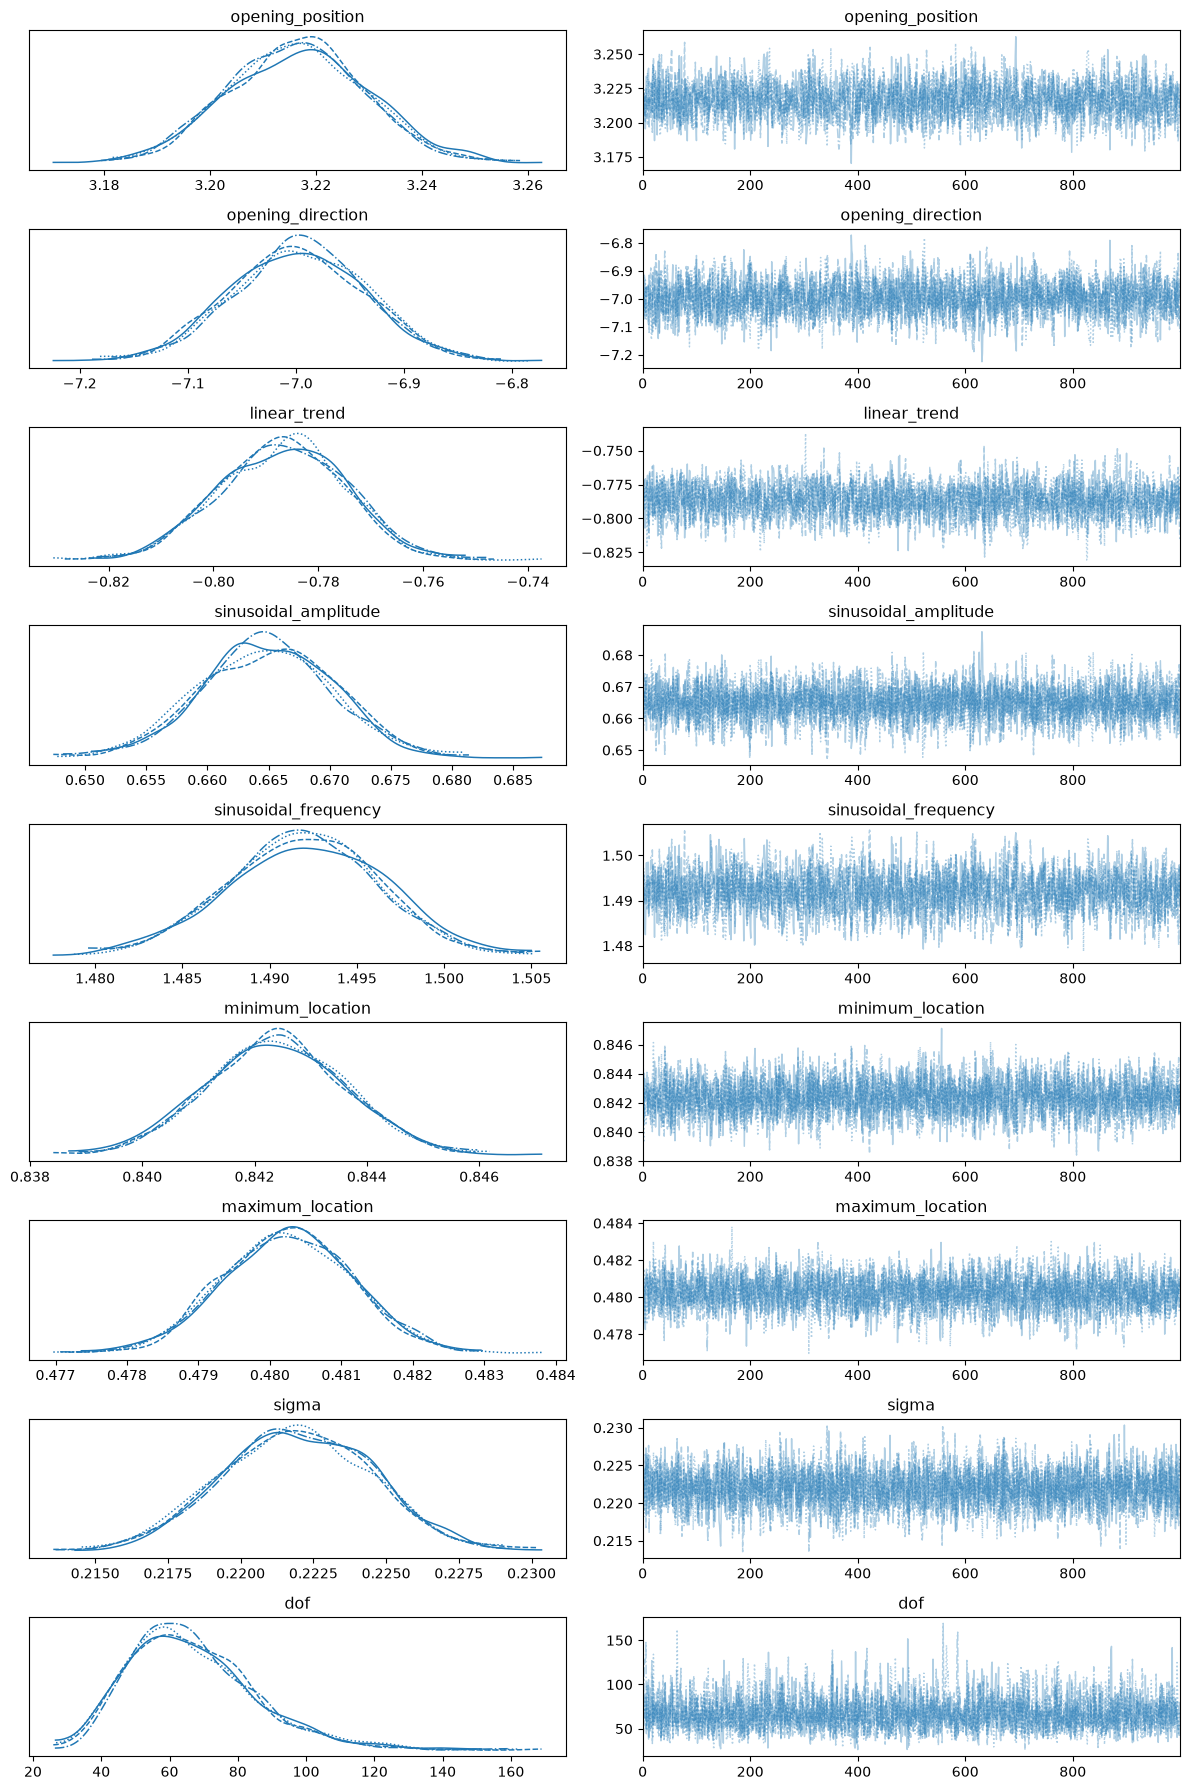

In [5]:
# Select the model results to summarise.
idata = model.idata

# List the quantities that will appear in the summary and trace plots.
parameter_names = [
    "opening_position",
    "opening_direction",
    "linear_trend",
    "sinusoidal_amplitude",
    "sinusoidal_frequency",
    "minimum_location",
    "maximum_location",
    "sigma",
    "dof",
]

# Show estimates, 95% HDIs, effective sample sizes, and R-hat values.
parameter_summary = az.summary(
    idata, var_names=parameter_names, hdi_prob=0.95, round_to=3
)
display(parameter_summary)

# Plot the chains to check that sampling mixed well.
az.plot_trace(idata, var_names=parameter_names, compact=True)
plt.tight_layout()
plt.show()

### Posterior predictive fit

The latent-mean HDI describes uncertainty in the fitted shape. The posterior-predictive HDI is wider because it also includes observation noise. Both intervals use `az.hdi`.

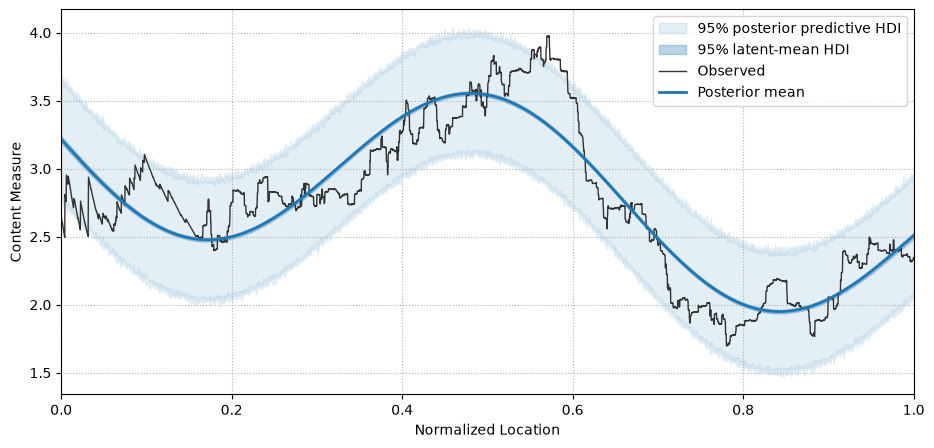

In [6]:
# Calculate the fitted mean and its 95% HDI.
fit_time = data["time"].to_numpy()
mu_posterior = idata.posterior["mu"]
mu_mean = mu_posterior.mean(dim=("chain", "draw")).values
mu_interval = az.hdi(mu_posterior, hdi_prob=0.95)["mu"]

# Calculate the 95% HDI for new observations predicted by the model.
predictive = idata.posterior_predictive["observed"]
predictive_interval = az.hdi(predictive, hdi_prob=0.95)["observed"]


# Plot the observed data, fitted mean, and both uncertainty intervals.
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(
    fit_time,
    predictive_interval.sel(hdi="lower").values,
    predictive_interval.sel(hdi="higher").values,
    color="C0",
    alpha=0.12,
    label="95% posterior predictive HDI",
)
ax.fill_between(
    fit_time,
    mu_interval.sel(hdi="lower").values,
    mu_interval.sel(hdi="higher").values,
    color="C0",
    alpha=0.30,
    label="95% latent-mean HDI",
)
ax.plot(fit_time, data["emo"], color="0.2", lw=1, label="Observed")
ax.plot(fit_time, mu_mean, color="C0", lw=2, label="Posterior mean")
ax.set(
    xlabel="Normalized Location",
    ylabel="Content Measure",
    xlim=(0, 1),
)
ax.grid(ls=":")
ax.legend()
plt.show()

## Fit alternative models

Fit constant, linear, and curvilinear models for comparison.

In [7]:
# Fit a constant model.
constant_model = cs.ConstantModel()
constant_model.time_data = data.time
constant_model.sequence_data = data.emo
constant_model.fit(progressbar=False)

# Fit a linear model.
linear_model = cs.LinearModel()
linear_model.time_data = data.time
linear_model.sequence_data = data.emo
linear_model.fit(progressbar=False)

# Fit a curvilinear (quadratic) model.
curvilinear_model = cs.QuadraticModel()
curvilinear_model.time_data = data.time
curvilinear_model.sequence_data = data.emo
curvilinear_model.fit(progressbar=False)

Sampling: [observed, polynomial_coeffs, sigma]
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [polynomial_coeffs, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [observed]
Sampling: [observed, polynomial_coeffs, sigma]
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [polynomial_coeffs, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.
Sampling: [observed]
Sampling: [observed, polynomial_coeffs, sigma]
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [polynomial_coeffs, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
Sampling: [observed]


Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

## Posterior Plots

### Constant Model

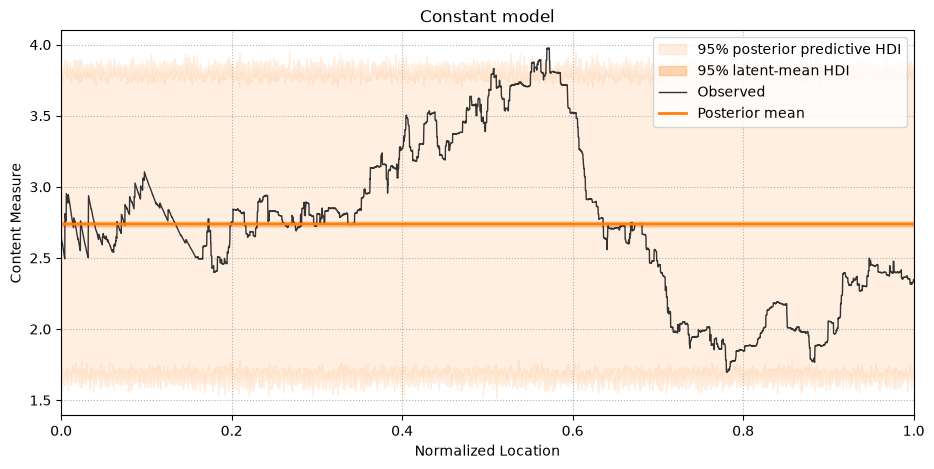

In [8]:
# This function draws the same posterior plot for each comparison model.
def plot_posterior_predictive_fit(fitted_model, title, color="C0"):
    """Plot posterior fit and predictive uncertainty for a fitted model."""
    model_idata = fitted_model.idata
    fit_time = data["time"].to_numpy()

    mu_posterior = model_idata.posterior["mu"]
    mu_mean = mu_posterior.mean(dim=("chain", "draw")).values
    mu_interval = az.hdi(mu_posterior, hdi_prob=0.95)["mu"]

    predictive = model_idata.posterior_predictive["observed"]
    predictive_interval = az.hdi(
        predictive, hdi_prob=0.95
    )["observed"]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.fill_between(
        fit_time,
        predictive_interval.sel(hdi="lower").values,
        predictive_interval.sel(hdi="higher").values,
        color=color,
        alpha=0.12,
        label="95% posterior predictive HDI",
    )
    ax.fill_between(
        fit_time,
        mu_interval.sel(hdi="lower").values,
        mu_interval.sel(hdi="higher").values,
        color=color,
        alpha=0.30,
        label="95% latent-mean HDI",
    )
    ax.plot(fit_time, data["emo"], color="0.2", lw=1, label="Observed")
    ax.plot(fit_time, mu_mean, color=color, lw=2, label="Posterior mean")
    ax.set(
        title=title,
        xlabel="Normalized Location",
        ylabel="Content Measure",
        xlim=(0, 1),
    )
    ax.grid(ls=":")
    ax.legend()
    plt.show()


# Plot the constant model.
plot_posterior_predictive_fit(constant_model, "Constant model", color="C1")

### Linear Model

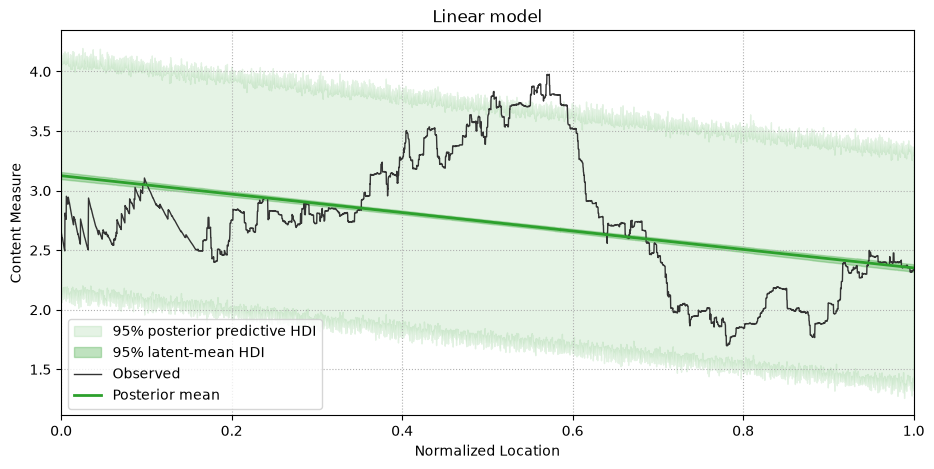

In [9]:
# Plot the linear model.
plot_posterior_predictive_fit(linear_model, "Linear model", color="C2")

### Curvilinear Model

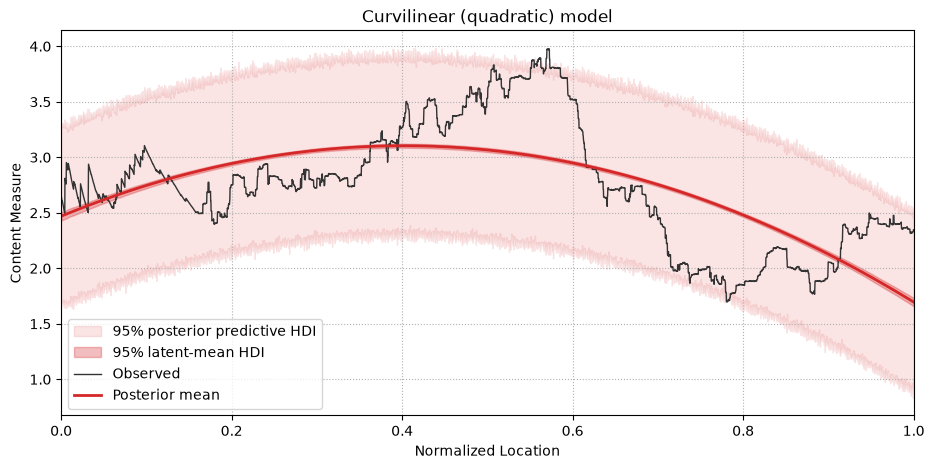

In [10]:
# Plot the curvilinear model.
plot_posterior_predictive_fit(
    curvilinear_model, "Curvilinear (quadratic) model", color="C3"
)

## LOO model comparison

We compare the four satisfactorily sampled models with approximate leave-one-out cross-validation and stacking weights. Review the `warning` column and Pareto diagnostics before using the ranking. Differences should be interpreted alongside their standard errors, predictive plots, and substantive plausibility rather than as an automatic model-selection rule.

In [11]:
# Compare predictive performance; the best-supported model has rank 0.
az.compare(
    {
        "Constant": constant_model.idata,
        "Linear": linear_model.idata,
        "Curvilinear": curvilinear_model.idata,
        "Linear + Sinusoidal": model.idata,
    },
    method="stacking",
    ic="loo",
)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Linear + Sinusoidal,0,302.484603,6.606319,0.000000,1.000000e+00,43.204407,0.000000,False,log
Curvilinear,1,-2261.321275,3.551269,2563.805878,0.000000e+00,37.457168,43.490491,False,log
Linear,2,-3139.693375,2.459521,3442.177978,1.552145e-13,42.637639,43.162869,False,log
Constant,3,-3521.431027,1.637509,3823.915631,6.945642e-14,37.855713,46.991413,False,log


## Extending the model

`cs.GenericPolynomialSinusoidalModel(N, M)` supports other polynomial degrees and harmonic counts with a bounded Student-t likelihood; `cs.GenericPolynomialSinusoidalNormalModel(N, M)` uses a bounded Normal likelihood. Their defaults scale to `sequence_bounds`, but increasing `N` or `M` introduces additional flexibility and potential identifiability problems. Generic models do not automatically add the paper-specific interpretation variables.